# Carga_EDA_muestra

El objetivo de este código es procesar y visualizar la muestra base de audios de DAIC-WOZ de acuerdo a lo descrito en el trabajo asociado, con la finalidad de poder extraer posteriormente features acústicas y explotarse en modelos predictivos

## 0. Setup
---

In [1]:
import os
import getpass
from pathlib import Path

import pandas as pd
import numpy as np

import librosa
import parselmouth
from parselmouth.praat import call

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Path con muestra
path_sample = r'D:/DAIZ-WOZ/base/'

# Archivos
path_labels_train = os.path.join(path_sample, 'Docs/train_split_Depression_AVEC2017.csv')
path_labels_dev = os.path.join(path_sample, 'Docs/dev_split_Depression_AVEC2017.csv')
path_labels_test = os.path.join(path_sample, 'Docs/full_test_split.csv')

# Speakers entrevista
name_paciente = 'Participant'
name_entrevistador = 'Ellie'

# Path guardado dataframe
path_output = Path(getpass.getpass("Ruta de guardado final: "))

## 1. Muestra en crudo
---

### 1.1 Carga

In [3]:
# Carga dfs train/dev
df_train = pd.read_csv(path_labels_train)
df_train['split'] = 'train'

df_dev   = pd.read_csv(path_labels_dev)
df_dev['split'] = 'dev'

# Concat de ambos
df_full = pd.concat([df_train, df_dev], ignore_index=True)
df_full

,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving,split
0,303,0,0,0,0,0,0.0,0,0,0,0,0,train
1,304,0,6,0,0,1,1.0,2,2,0,0,0,train
2,305,0,7,1,0,1,1.0,2,2,1,0,0,train
3,310,0,4,1,1,1,0.0,0,0,1,1,0,train
4,312,0,2,1,0,0,1.0,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,483,1,15,1,0,1,3.0,3,3,2,3,0,dev
138,484,0,9,0,1,1,0.0,3,1,2,1,0,dev
139,489,0,3,1,0,1,2.0,0,0,0,0,0,dev
140,490,0,2,1,0,1,0.0,1,0,0,0,0,dev


In [4]:
# Se filtran columnas de interés y se añade split de test
df_full = df_full[['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender', 'split']]

df_test = pd.read_csv(path_labels_test)
df_test['split'] = 'test'
df_test = df_test.rename(
    columns={
        'PHQ_Binary': 'PHQ8_Binary',
        'PHQ_Score': 'PHQ8_Score'
    }
)

df_full = pd.concat([df_full, df_test], ignore_index=True)

# Formateo columnas
df_full.columns = df_full.columns.str.strip().str.lower()
df_full = df_full.sort_values(by='participant_id').reset_index(drop=True)

Se eliminan las 3 sesiones sin información del asistente en sus transcripciones: **451, 458, 480**

In [5]:
sesiones_noInfo = [451, 458, 480]

df_filt = df_full[~df_full['participant_id'].isin(sesiones_noInfo)].reset_index(drop=True)

n_eliminadas = len(df_full) - len(df_filt)
pct_eliminadas = n_eliminadas / len(df_full) * 100

print(f'Eliminadas {n_eliminadas} sesiones ({pct_eliminadas:.1f}% de la muestra)')

Eliminadas 3 sesiones (1.6% de la muestra)


In [6]:
df_filt

,participant_id,phq8_binary,phq8_score,gender,split
0,300,0,2,1,test
1,301,0,3,1,test
2,302,0,4,1,dev
3,303,0,0,0,train
4,304,0,6,0,train
...,...,...,...,...,...
181,488,0,0,0,train
182,489,0,3,1,dev
183,490,0,2,1,dev
184,491,0,8,0,train


### 1.2 Cálculo de variables

In [7]:
# Path con el audio
df_filt['path_audio'] = [path_sample + str(N) + '_P/' + str(N) + '_AUDIO.wav' for N in df_filt['participant_id'].values]

# Path con la transcripción
df_filt['path_transcript'] = [path_sample + str(N) + '_P/' + str(N) + '_TRANSCRIPT.csv' for N in df_filt['participant_id'].values]
df_filt

,participant_id,phq8_binary,phq8_score,gender,split,path_audio,path_transcript
0,300,0,2,1,test,D:/DAIZ-WOZ/base/300_P/300_AUDIO.wav,D:/DAIZ-WOZ/base/300_P/300_TRANSCRIPT.csv
1,301,0,3,1,test,D:/DAIZ-WOZ/base/301_P/301_AUDIO.wav,D:/DAIZ-WOZ/base/301_P/301_TRANSCRIPT.csv
2,302,0,4,1,dev,D:/DAIZ-WOZ/base/302_P/302_AUDIO.wav,D:/DAIZ-WOZ/base/302_P/302_TRANSCRIPT.csv
3,303,0,0,0,train,D:/DAIZ-WOZ/base/303_P/303_AUDIO.wav,D:/DAIZ-WOZ/base/303_P/303_TRANSCRIPT.csv
4,304,0,6,0,train,D:/DAIZ-WOZ/base/304_P/304_AUDIO.wav,D:/DAIZ-WOZ/base/304_P/304_TRANSCRIPT.csv
...,...,...,...,...,...,...,...
181,488,0,0,0,train,D:/DAIZ-WOZ/base/488_P/488_AUDIO.wav,D:/DAIZ-WOZ/base/488_P/488_TRANSCRIPT.csv
182,489,0,3,1,dev,D:/DAIZ-WOZ/base/489_P/489_AUDIO.wav,D:/DAIZ-WOZ/base/489_P/489_TRANSCRIPT.csv
183,490,0,2,1,dev,D:/DAIZ-WOZ/base/490_P/490_AUDIO.wav,D:/DAIZ-WOZ/base/490_P/490_TRANSCRIPT.csv
184,491,0,8,0,train,D:/DAIZ-WOZ/base/491_P/491_AUDIO.wav,D:/DAIZ-WOZ/base/491_P/491_TRANSCRIPT.csv


Una vez filtrado el dataset, se calculan variables para realizar un EDA preliminar pre procesamiento.
Las variables se calculan a nivel turno real, no registro a registro, y para el paciente, que es el que proporciona información de interés clínico:

* <u>Archivo de audio</u>
* **Duración del audio**: duración del archivo de audio en segundos

* <u>Transcripciones</u>
    * <u>Tiempo hablado</u>
        * **Duración de la entrevista**: tiempo entre el comienzo de la primera intervención y el final de la última
        * **Número de turnos**: número de veces en que el paciente habla
        * **Tiempo total hablado**: suma de duración de los turnos completos
        * **Media de tiempo hablado**: media de tiempo de duración de los turnos completos
        * **Desviación estandar de tiempo hablado**: desviación estándar de tiempo de duración de los turnos completos
        * **Ratio de habla respecto de total**: porcentaje de tiempo de turno del paciente respecto del tiempo total (de la sesión)
    * <u>Pausas interturno</u>
        * **Tiempo total de pausas interturno**: silencio entre turnos (tiempo de respuesta del paciente ante una pregunta)
        * **Media de tiempo total de pausas interturno**: media de tiempo de silencio entre turnos
        * **Desviación estándar de tiempo total de pausas interturno**: desviación estándar de tiempo de silencio entre turnos
        * **Ratio de pausa interturno respecto del total hablado**: porcentaje de tiempo de pausa interturno del paciente respecto del tiempo total (de la sesión)

In [8]:
def get_duration_audio(path_audio):
    """
    UDF: devuelve duración en segundos de audio dada su ruta
    """

    if not isinstance(path_audio, str) or not os.path.exists(path_audio):
        return np.nan
    
    try:
        return librosa.get_duration(path=path_audio)
    
    except Exception:
        return np.nan



def build_turns(transcript_path,
                speaker_col="speaker",
                start_col="start_time",
                stop_col="stop_time"
                ):

    """
    Calcula un df con los turnos reales y tiempos de comienzo y fin
    a partir del csv de transcripciones
    """

    df = pd.read_csv(transcript_path, sep='\t')
    df.columns = df.columns.str.strip()

    df = df.sort_values(start_col).reset_index(drop=True)

    # Excluir filas no verbales: <laughter>, <cough>, <synch>, etc.
    df = df[~df['value'].str.strip().str.startswith('<', na=False)].reset_index(drop=True)

    # detectar cambios de speaker consecutivos
    df["turn_id"] = (df[speaker_col] != df[speaker_col].shift()).cumsum()

    # Agrupar por turnos
    df_turns = (
        df.groupby("turn_id")
          .agg(
              speaker=(speaker_col, "first"),
              start_time=(start_col, "min"),
              stop_time=(stop_col, "max")
          )
          .reset_index(drop=True)
    )

    return df_turns



def calc_metrics_turns_pat(
    turns_df,
    speaker_col="speaker",
    start_col="start_time",
    end_col="stop_time",
    speaker_label=name_paciente
):
    """
    Calcula métricas de tiempo de habla del paciente por turno.
    Todas las duraciones se devuelven en segundos
    """

    patient = turns_df[turns_df[speaker_col] == speaker_label].copy()

    if len(patient) == 0:
        return {
            "durSession": 0.0,
            "nTurns_pat": 0,
            "sumTurns_pat": 0.0,
            "avgTurns_pat": 0.0,
            "stdTurns_pat": 0.0,
            "ratioTurns_pat": 0.0
        }

    # Duración de cada turno (s)
    durations = (patient[end_col] - patient[start_col])

    total_speaking = durations.sum()

    # Duración total sesión (s)
    session_duration = (
        turns_df[end_col].max() - turns_df[start_col].min()
    )

    return {
        "durSession": float(session_duration),
        "nTurns_pat": int(len(patient)),
        "sumTurns_pat": float(total_speaking),
        "avgTurns_pat": float(durations.mean()),
        "stdTurns_pat": float(
            durations.std(ddof=1)
        ) if len(durations) > 1 else 0.0,
        "ratioTurns_pat": float(
            total_speaking / session_duration
        ) if session_duration > 0 else np.nan
    }



def calc_metrics_pauseInter_pat(
    turns_df,
    speaker_col="speaker",
    start_col="start_time",
    end_col="stop_time",
    speaker_patient=name_paciente,
    speaker_interviewer=name_entrevistador
):
    """
    Calcula latencia de respuesta del paciente.
    Todas las duraciones se devuelven en segundos.
    """

    df = turns_df.sort_values(start_col).reset_index(drop=True)

    pauses = []

    for i in range(len(df) - 1):

        current_speaker = df.loc[i, speaker_col]
        next_speaker = df.loc[i + 1, speaker_col]

        current_end = df.loc[i, end_col]
        next_start = df.loc[i + 1, start_col]

        pause = (next_start - current_end)

        if (
            current_speaker == speaker_interviewer
            and next_speaker == speaker_patient
            and pause > 0
        ):
            pauses.append(pause)

    if len(pauses) == 0:
        return {
            "sumPause_inter_pat": 0.0,
            "avgPause_inter_pat": 0.0,
            "stdPause_inter_pat": 0.0,
            "ratioPause_inter_pat": 0.0
        }

    pauses = np.array(pauses)

    session_duration = (
        df[end_col].max() - df[start_col].min()
    )

    return {
        "sumPause_inter_pat": float(pauses.sum()),
        "avgPause_inter_pat": float(pauses.mean()),
        "stdPause_inter_pat": float(
            pauses.std(ddof=1)
        ) if len(pauses) > 1 else 0.0,
        "ratioPause_inter_pat": float(
            pauses.sum() / session_duration
        ) if session_duration > 0 else np.nan
    }



def execute_basicMetrics(row):
    """
    Pipeline completo:
    transcript -> turnos -> métricas de turnos -> métricas de latencia
    """

    try:

        path_transcript = row["path_transcript"]

        turns_df = build_turns(path_transcript)

        if turns_df is None or len(turns_df) == 0:
            raise ValueError("Transcript vacío")

        turn_feats = calc_metrics_turns_pat(turns_df)

        pause_feats = calc_metrics_pauseInter_pat(turns_df)

        return {
            **turn_feats,
            **pause_feats
        }

    except Exception as e:
        print(f"ERROR: {e}")

        return {
            "durSession": np.nan,
            "nTurns_pat": np.nan,
            "sumTurns_pat": np.nan,
            "avgTurns_pat": np.nan,
            "stdTurns_pat": np.nan,
            "ratioTurns_pat": np.nan,
            "sumPause_inter_pat": np.nan,
            "avgPause_inter_pat": np.nan,
            "stdPause_inter_pat": np.nan,
            "ratioPause_inter_pat": np.nan
        }

In [9]:
features = pd.json_normalize(df_filt.apply(execute_basicMetrics, axis=1))

df_filt['durAudio'] = df_filt['path_audio'].apply(get_duration_audio)

df_features_1 = pd.concat([df_filt, features], axis=1)
df_features_1

c:\Users\tblxa\Desktop\Master\UNIR_IA_TFE\unir_tfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,participant_id,phq8_binary,phq8_score,gender,split,path_audio,path_transcript,durAudio,durSession,nTurns_pat,sumTurns_pat,avgTurns_pat,stdTurns_pat,ratioTurns_pat,sumPause_inter_pat,avgPause_inter_pat,stdPause_inter_pat,ratioPause_inter_pat
0,300,0,2,1,test,D:/DAIZ-WOZ/base/300_P/300_AUDIO.wav,D:/DAIZ-WOZ/base/300_P/300_TRANSCRIPT.csv,648.5,584.680,58,181.090,3.122241,3.037682,0.309725,93.710,1.673393,1.786927,0.160276
1,301,0,3,1,test,D:/DAIZ-WOZ/base/301_P/301_AUDIO.wav,D:/DAIZ-WOZ/base/301_P/301_TRANSCRIPT.csv,823.9,774.400,48,540.870,11.268125,13.004461,0.698438,37.070,0.823778,0.638970,0.047869
2,302,0,4,1,dev,D:/DAIZ-WOZ/base/302_P/302_AUDIO.wav,D:/DAIZ-WOZ/base/302_P/302_TRANSCRIPT.csv,758.8,676.970,52,284.032,5.462154,5.823339,0.419564,97.925,1.958500,1.242940,0.144652
3,303,0,0,0,train,D:/DAIZ-WOZ/base/303_P/303_AUDIO.wav,D:/DAIZ-WOZ/base/303_P/303_TRANSCRIPT.csv,985.3,934.100,57,668.570,11.729298,12.520528,0.715737,49.060,0.981200,1.493923,0.052521
4,304,0,6,0,train,D:/DAIZ-WOZ/base/304_P/304_AUDIO.wav,D:/DAIZ-WOZ/base/304_P/304_TRANSCRIPT.csv,792.6,720.040,72,404.640,5.620000,7.030951,0.561969,50.870,0.726714,0.887816,0.070649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,488,0,0,0,train,D:/DAIZ-WOZ/base/488_P/488_AUDIO.wav,D:/DAIZ-WOZ/base/488_P/488_TRANSCRIPT.csv,884.9,833.100,39,541.550,13.885897,13.608864,0.650042,43.398,1.172919,1.457796,0.052092
182,489,0,3,1,dev,D:/DAIZ-WOZ/base/489_P/489_AUDIO.wav,D:/DAIZ-WOZ/base/489_P/489_TRANSCRIPT.csv,704.7,644.098,65,210.740,3.242154,4.010237,0.327186,140.985,2.237857,1.758847,0.218887
183,490,0,2,1,dev,D:/DAIZ-WOZ/base/490_P/490_AUDIO.wav,D:/DAIZ-WOZ/base/490_P/490_TRANSCRIPT.csv,691.3,650.478,51,255.610,5.011961,4.669472,0.392957,117.441,2.302765,1.825454,0.180546
184,491,0,8,0,train,D:/DAIZ-WOZ/base/491_P/491_AUDIO.wav,D:/DAIZ-WOZ/base/491_P/491_TRANSCRIPT.csv,881.7,797.940,58,500.180,8.623793,7.975798,0.626839,39.167,0.870378,1.285966,0.049085


Sin embargo, también es interesante estudiar las pausas intraturno. Para esto, se necesita tanto la información de transcripción (para saber en qué momento habla cada participante) como la del audio (para medir de forma automática las pausas). Se medirán sólo las del paciente, que son las relevantes clínicamente.

Se calcula:

* <u>Pausas intraturno</u>
    * **Número de pausas intraturno**: número de pausas intraturno
    * **Tiempo total de pausas intraturno**: silencios dentro de un mismo turno
    * **Media de tiempo total de pausas intraturno**: media de tiempo de silencios de un mismo turno
    * **Desviación estándar de tiempo total de pausas intraturno**: desviación estándar de tiempo de silencios de un mismo turno
    * **Ratio de pausa intraturno respecto del total hablado**: porcentaje de pausa intraturno respecto del tiempo total (de la sesión)

Para esto, se utiliza la librería de **parselmouth**

In [10]:
def _empty_intra_metrics():
    return {
        "nPause_intra_pat": 0,
        "sumPause_intra_pat": 0.0,
        "avgPause_intra_pat": 0.0,
        "stdPause_intra_pat": 0.0,
        "ratioPause_intra_pat": 0.0
    }


def calc_metrics_pauseIntra_pat(
    transcript_path,
    speaker_col="speaker",
    start_col="start_time",
    end_col="stop_time",
    speaker_patient=name_paciente,
    min_pause_dur=0.25
):
    """
    Calcula pausas intraturno del paciente a partir de los gaps entre segmentos
    consecutivos del transcript dentro del mismo turno real.

    El transcript de DAIC-WOZ anota a nivel de frase/palabra; el gap entre el
    fin de un segmento y el inicio del siguiente (dentro del mismo turno real)
    es una pausa natural del discurso —la fuente de verdad anotada manualmente.

    Se descartan gaps negativos (solapamientos de anotación) y los menores al
    umbral clínico estándar de 0.25 s (Zuckerman et al., 1981).

    Parámetros
    ----------
    transcript_path : str
        Ruta al TRANSCRIPT.csv de la sesión.
    min_pause_dur : float
        Umbral mínimo en segundos para considerar un gap como pausa.
    """
    df = pd.read_csv(transcript_path, sep='\t')
    df.columns = df.columns.str.strip()
    df = df.sort_values(start_col).reset_index(drop=True)

    # Excluir filas no verbales: <laughter>, <cough>, <synch>, etc.
    df = df[~df['value'].str.strip().str.startswith('<', na=False)].reset_index(drop=True)

    # Turno real = bloque contiguo de filas del mismo speaker sin interrupción
    df["turn_id"] = (df[speaker_col] != df[speaker_col].shift()).cumsum()

    df_pat = df[df[speaker_col] == speaker_patient].copy()

    if df_pat.empty:
        return _empty_intra_metrics()

    pauses = []

    for _, group in df_pat.groupby("turn_id", sort=True):
        group = group.sort_values(start_col).reset_index(drop=True)

        if len(group) < 2:
            continue  # turno de un solo segmento → sin pausas intraturno

        # Gap = inicio del segmento i+1 - fin del segmento i
        gaps = group[start_col].values[1:] - group[end_col].values[:-1]

        # Solo gaps estrictamente positivos y >= umbral clínico
        valid = gaps[(gaps > 0) & (gaps >= min_pause_dur)]
        pauses.extend(valid.tolist())

    if not pauses:
        return _empty_intra_metrics()

    pauses = np.array(pauses)

    return {
        "nPause_intra_pat": int(len(pauses)),
        "sumPause_intra_pat": float(pauses.sum()),
        "avgPause_intra_pat": float(pauses.mean()),
        "stdPause_intra_pat": float(pauses.std(ddof=1)) if len(pauses) > 1 else 0.0,
    }


def execute_intraMetrics(row,
                         speaker_patient=name_paciente,
                         min_pause_dur=0.25
                         ):
    """
    Pipeline: transcript -> pausas intraturno del paciente.

    Usa los gaps del transcript (ground truth anotado) en lugar de análisis
    acústico, evitando artefactos de borde que Praat introduce al analizar
    segmentos de turno completo (silencio previo y posterior a la voz).
    """
    try:
        path_transcript = row["path_transcript"]
        dur_session = float(row["durSession"])

        metrics = calc_metrics_pauseIntra_pat(
            path_transcript,
            speaker_patient=speaker_patient,
            min_pause_dur=min_pause_dur
        )

        ratio = (
            float(metrics["sumPause_intra_pat"] / dur_session)
            if dur_session > 0 else np.nan
        )

        return {**metrics, "ratioPause_intra_pat": ratio}

    except Exception as e:
        print(f"ERROR sesión {row.get('participant_id', '?')}: {e}")
        return _empty_intra_metrics()


In [11]:
df_intra = pd.json_normalize(df_features_1.apply(execute_intraMetrics, axis=1))
df_features_2 = pd.concat([df_features_1, df_intra], axis=1)
df_features_2

,participant_id,phq8_binary,phq8_score,gender,split,path_audio,path_transcript,durAudio,durSession,nTurns_pat,...,ratioTurns_pat,sumPause_inter_pat,avgPause_inter_pat,stdPause_inter_pat,ratioPause_inter_pat,nPause_intra_pat,sumPause_intra_pat,avgPause_intra_pat,stdPause_intra_pat,ratioPause_intra_pat
0,300,0,2,1,test,D:/DAIZ-WOZ/base/300_P/300_AUDIO.wav,D:/DAIZ-WOZ/base/300_P/300_TRANSCRIPT.csv,648.5,584.680,58,...,0.309725,93.710,1.673393,1.786927,0.160276,29,25.330,0.873448,0.454503,0.043323
1,301,0,3,1,test,D:/DAIZ-WOZ/base/301_P/301_AUDIO.wav,D:/DAIZ-WOZ/base/301_P/301_TRANSCRIPT.csv,823.9,774.400,48,...,0.698438,37.070,0.823778,0.638970,0.047869,56,65.430,1.168393,0.526539,0.084491
2,302,0,4,1,dev,D:/DAIZ-WOZ/base/302_P/302_AUDIO.wav,D:/DAIZ-WOZ/base/302_P/302_TRANSCRIPT.csv,758.8,676.970,52,...,0.419564,97.925,1.958500,1.242940,0.144652,44,75.542,1.716864,0.914819,0.111588
3,303,0,0,0,train,D:/DAIZ-WOZ/base/303_P/303_AUDIO.wav,D:/DAIZ-WOZ/base/303_P/303_TRANSCRIPT.csv,985.3,934.100,57,...,0.715737,49.060,0.981200,1.493923,0.052521,45,46.540,1.034222,0.741526,0.049823
4,304,0,6,0,train,D:/DAIZ-WOZ/base/304_P/304_AUDIO.wav,D:/DAIZ-WOZ/base/304_P/304_TRANSCRIPT.csv,792.6,720.040,72,...,0.561969,50.870,0.726714,0.887816,0.070649,32,42.040,1.313750,1.261898,0.058386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,488,0,0,0,train,D:/DAIZ-WOZ/base/488_P/488_AUDIO.wav,D:/DAIZ-WOZ/base/488_P/488_TRANSCRIPT.csv,884.9,833.100,39,...,0.650042,43.398,1.172919,1.457796,0.052092,97,121.110,1.248557,2.412238,0.145373
182,489,0,3,1,dev,D:/DAIZ-WOZ/base/489_P/489_AUDIO.wav,D:/DAIZ-WOZ/base/489_P/489_TRANSCRIPT.csv,704.7,644.098,65,...,0.327186,140.985,2.237857,1.758847,0.218887,40,54.010,1.350250,1.000673,0.083854
183,490,0,2,1,dev,D:/DAIZ-WOZ/base/490_P/490_AUDIO.wav,D:/DAIZ-WOZ/base/490_P/490_TRANSCRIPT.csv,691.3,650.478,51,...,0.392957,117.441,2.302765,1.825454,0.180546,41,74.400,1.814634,1.599202,0.114377
184,491,0,8,0,train,D:/DAIZ-WOZ/base/491_P/491_AUDIO.wav,D:/DAIZ-WOZ/base/491_P/491_TRANSCRIPT.csv,881.7,797.940,58,...,0.626839,39.167,0.870378,1.285966,0.049085,84,95.970,1.142500,1.040982,0.120272


### 1.3 Visualización

In [12]:
sns.set_theme(style="whitegrid", palette="muted")

NCOLS = 5

GROUP_LABELS = [
    "Tiempo de habla",
    "Pausas interturno",
    "Pausas intraturno",
]

VAR_GROUPS = [
    [
        ("nTurns_pat",     "N.º de turnos"),
        ("sumTurns_pat",   "Tiempo total (s)"),
        ("avgTurns_pat",   "Dur. media (s)"),
        ("stdTurns_pat",   "Desv. típica (s)"),
        ("ratioTurns_pat", "Ratio / sesión"),
    ],
    [
        ("sumPause_inter_pat",   "Tiempo total (s)"),
        ("avgPause_inter_pat",   "Media (s)"),
        ("stdPause_inter_pat",   "Desv. típica (s)"),
        ("ratioPause_inter_pat", "Ratio / sesión"),
    ],
    [
        ("nPause_intra_pat",     "N.º de pausas"),
        ("sumPause_intra_pat",   "Tiempo total (s)"),
        ("avgPause_intra_pat",   "Media (s)"),
        ("stdPause_intra_pat",   "Desv. típica (s)"),
        ("ratioPause_intra_pat", "Ratio / sesión"),
    ],
]

NROWS = len(VAR_GROUPS)


def _make_grid(h_per_row=3.2):
    return plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 3.5, NROWS * h_per_row))


def _label_rows(axes):
    for row_idx, label in enumerate(GROUP_LABELS):
        axes[row_idx, 0].set_ylabel(label, fontsize=10, fontweight="bold", labelpad=12)


def _hide_unused(axes, row_idx, n_used):
    for col_idx in range(n_used, NCOLS):
        axes[row_idx, col_idx].set_visible(False)


# ── 1. Distribución del PHQ-8 ─────────────────────────────────────────────────
def plot_phq8distribution_by_split(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(df["phq8_score"], bins=15, color="#2E86AB", edgecolor="white", linewidth=0.5)
    axes[0].axvline(10, color="red", linestyle="--", linewidth=1.2, label="Umbral clínico (PHQ-8 ≥ 10)")
    axes[0].set_title("Distribución PHQ-8 — Total", fontweight="bold")
    axes[0].set_xlabel("PHQ-8 score")
    axes[0].set_ylabel("Número de sesiones")
    axes[0].legend(fontsize=9)

    for split, color in [("train", "#2E86AB"), ("dev", "#37CE5DB3"), ("test", "#E84855")]:
        subset = df[df["split"] == split]["phq8_score"]
        axes[1].hist(subset, bins=15, alpha=0.6, color=color, edgecolor="white", linewidth=0.5, label=split)
    axes[1].axvline(10, color="red", linestyle="--", linewidth=1.2, label="Umbral clínico (PHQ-8 ≥ 10)")
    axes[1].set_title("Distribución PHQ-8 — Train vs Dev vs Test", fontweight="bold")
    axes[1].set_xlabel("PHQ-8 score")
    axes[1].set_ylabel("Número de sesiones")
    axes[1].legend(fontsize=9)

    for ax in axes:
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Distribución del target (PHQ-8)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print("── PHQ-8 stats ──")
    print(df.groupby("split")["phq8_score"].describe().round(2))
    severos = (df["phq8_score"] >= 10).sum()
    print(f"\nSesiones con PHQ-8 ≥ 10 (umbral clínico): {severos} / {len(df)} ({severos/len(df)*100:.1f}%)")


# ── 2. Variables vs PHQ-8 ────────────────────────────────────────────────────
def plot_vars_vs_phq8(df):
    fig, axes = _make_grid()

    for row_idx, group in enumerate(VAR_GROUPS):
        for col_idx, (col, label) in enumerate(group):
            ax = axes[row_idx, col_idx]
            if col not in df.columns:
                ax.set_visible(False)
                continue

            ax.scatter(df["phq8_score"], df[col], alpha=0.5, s=25, color="#2E86AB", edgecolors="none")

            mask = df[col].notna() & df["phq8_score"].notna()
            if mask.sum() > 2:
                z = np.polyfit(df.loc[mask, "phq8_score"], df.loc[mask, col], 1)
                x_line = np.linspace(df["phq8_score"].min(), df["phq8_score"].max(), 100)
                ax.plot(x_line, np.poly1d(z)(x_line), color="#E84855", linewidth=1.5, linestyle="--")
                r = df.loc[mask, ["phq8_score", col]].corr().iloc[0, 1]
                ax.set_title(f"{label}\nr = {r:.2f}", fontsize=9, fontweight="bold")
            else:
                ax.set_title(label, fontsize=9, fontweight="bold")

            ax.set_xlabel("PHQ-8 score", fontsize=8)
            ax.spines[["top", "right"]].set_visible(False)

        _hide_unused(axes, row_idx, len(group))

    _label_rows(axes)
    plt.suptitle("Variables del paciente vs PHQ-8", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ── 3. Boxplots por grupo de severidad ──────────────────────────────────────
def plot_boxplots_by_severity(df):
    df = df.copy()
    df["severity"] = pd.cut(
        df["phq8_score"],
        bins=[-1, 4, 9, 14, 24],
        labels=["Mínima\n(0-4)", "Leve\n(5-9)", "Moderada\n(10-14)", "Severa\n(15+)"]
    )

    fig, axes = _make_grid(h_per_row=3.5)
    palette = ["#8ecae6", "#219ebc", "#fb8500", "#e63946"]

    for row_idx, group in enumerate(VAR_GROUPS):
        for col_idx, (col, label) in enumerate(group):
            ax = axes[row_idx, col_idx]
            if col not in df.columns:
                ax.set_visible(False)
                continue

            sns.boxplot(data=df, x="severity", y=col, palette=palette,
                        ax=ax, linewidth=0.8, fliersize=3)
            ax.set_title(label, fontsize=9, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis='x', labelsize=8)
            ax.spines[["top", "right"]].set_visible(False)

        _hide_unused(axes, row_idx, len(group))

    _label_rows(axes)
    plt.suptitle("Variables del paciente por grupo de severidad (PHQ-8)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ── 4.1 Distribución por split (histograma) ─────────────────────────────────
def plot_vars_by_split(df):
    splits_colors = [("train", "#2E86AB"), ("dev", "#37CE5D"), ("test", "#E848556E")]
    splits_presentes = [s for s, _ in splits_colors if s in df["split"].unique()]

    fig, axes = _make_grid()

    for row_idx, group in enumerate(VAR_GROUPS):
        for col_idx, (col, label) in enumerate(group):
            ax = axes[row_idx, col_idx]
            if col not in df.columns:
                ax.set_visible(False)
                continue

            bins = np.linspace(df[col].min(), df[col].max(), 16)
            for split, color in splits_colors:
                if split not in splits_presentes:
                    continue
                subset = df[df["split"] == split][col].dropna()
                ax.hist(subset, bins=bins, alpha=0.6, color=color, edgecolor="white",
                        linewidth=0.4, label=split, density=True)

            ax.set_title(label, fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.spines[["top", "right"]].set_visible(False)

        _hide_unused(axes, row_idx, len(group))

    _label_rows(axes)
    plt.suptitle("Distribución de variables por split (histograma)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# ── 4.2 Distribución por split (KDE) ────────────────────────────────────────
def plot_vars_by_split_kde(df):
    splits_colors = [("train", "#2E86AB"), ("dev", "#E84855"), ("test", "#2CA02C")]
    splits_presentes = [s for s, _ in splits_colors if s in df["split"].unique()]

    fig, axes = _make_grid()

    for row_idx, group in enumerate(VAR_GROUPS):
        for col_idx, (col, label) in enumerate(group):
            ax = axes[row_idx, col_idx]
            if col not in df.columns:
                ax.set_visible(False)
                continue

            for split, color in splits_colors:
                if split not in splits_presentes:
                    continue
                subset = df[df["split"] == split][col].dropna()
                if len(subset) < 2:
                    continue
                sns.kdeplot(subset, ax=ax, color=color, label=split,
                            linewidth=2, fill=True, alpha=0.15)
                sns.kdeplot(subset, ax=ax, color=color, linewidth=2, fill=False)

            ax.set_title(label, fontsize=9, fontweight="bold")
            ax.legend(fontsize=7)
            ax.spines[["top", "right"]].set_visible(False)

        _hide_unused(axes, row_idx, len(group))

    _label_rows(axes)
    plt.suptitle("Distribución de variables por split (KDE)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

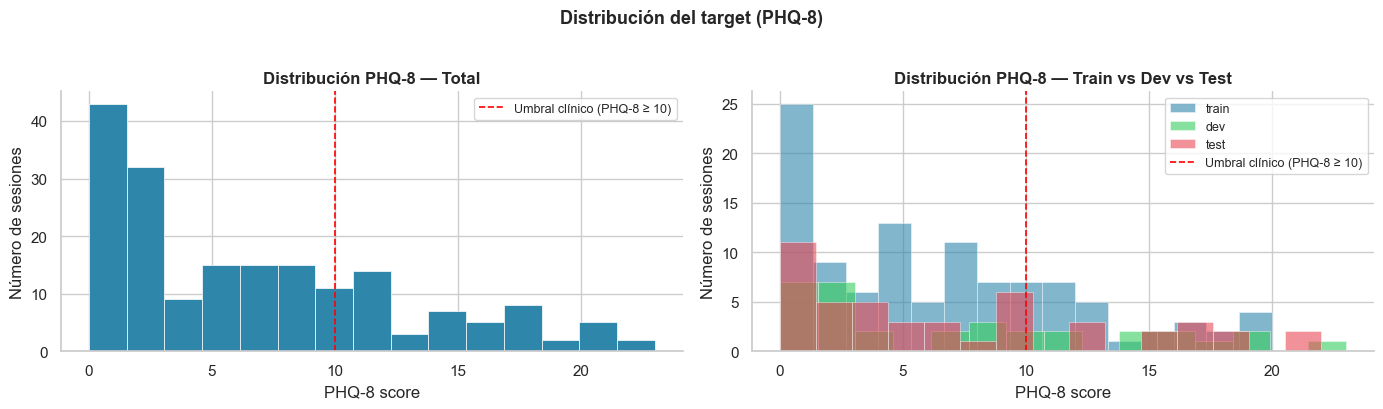

── PHQ-8 stats ──
       count  mean   std  min  25%  50%   75%   max
split                                              
dev     33.0  7.61  6.75  0.0  2.0  7.0  12.0  23.0
test    46.0  7.11  6.48  0.0  2.0  5.0  11.5  22.0
train  107.0  6.42  5.46  0.0  2.0  6.0  10.0  20.0

Sesiones con PHQ-8 ≥ 10 (umbral clínico): 57 / 186 (30.6%)


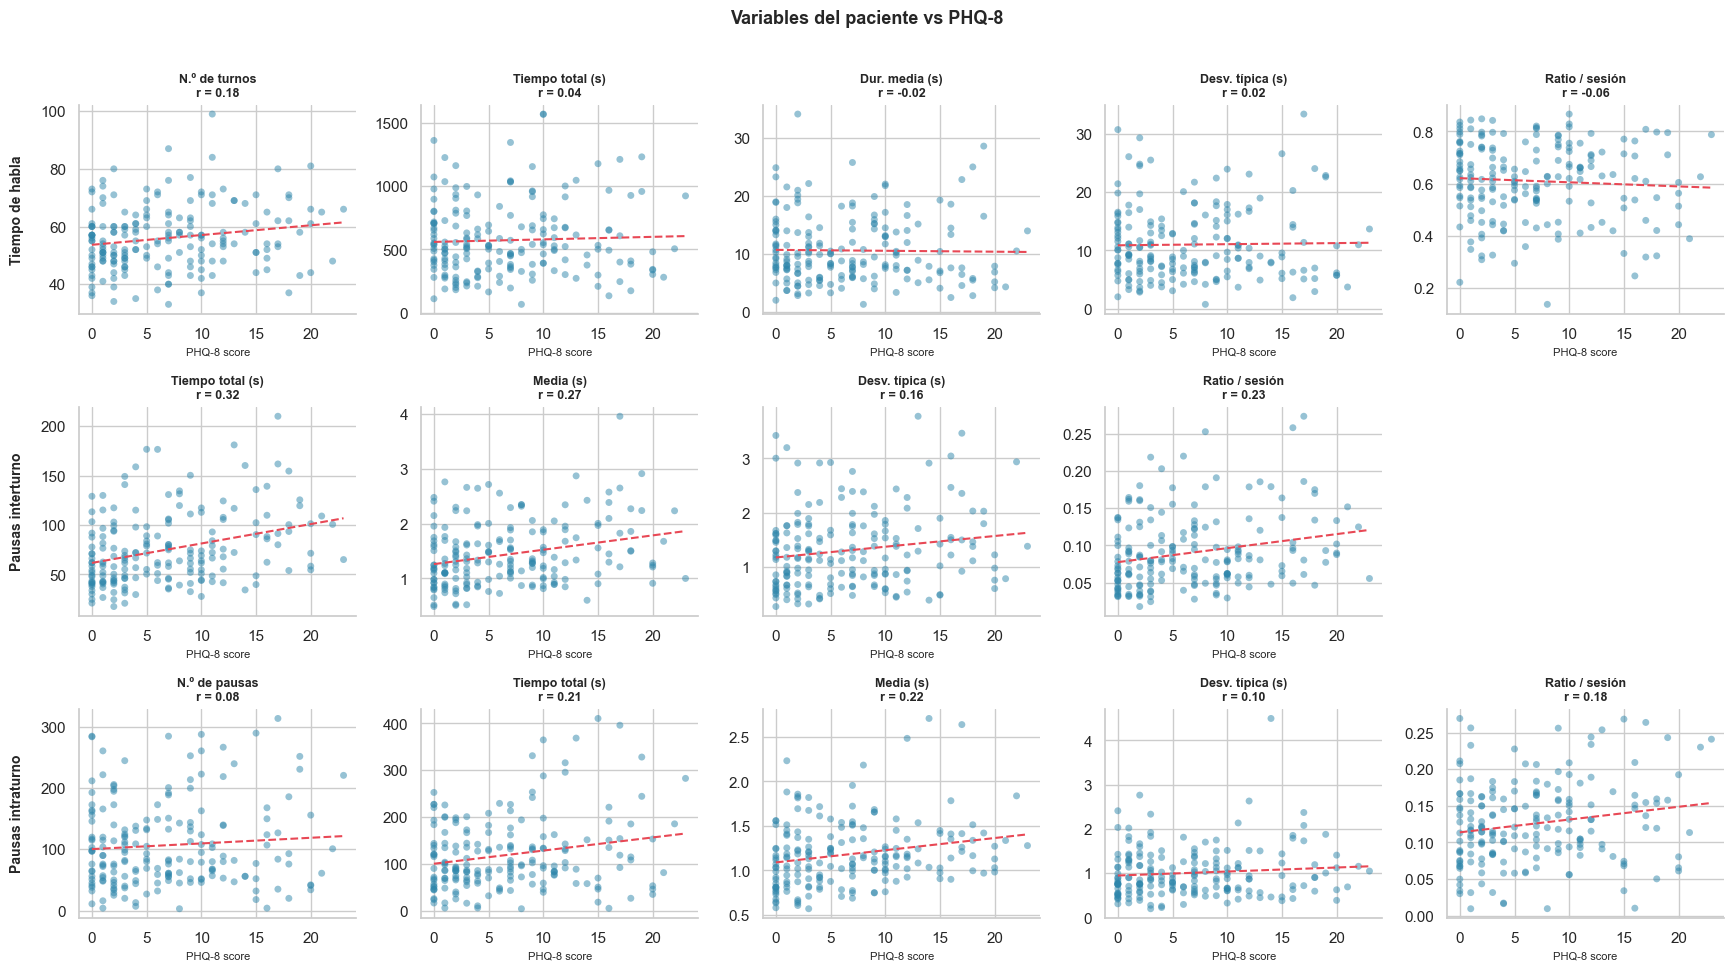

C:\Users\tblxa\AppData\Local\Temp\ipykernel_1336\3419499780.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col, palette=palette,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_1336\3419499780.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col, palette=palette,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_1336\3419499780.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y=col, palette=palette,
C:\Users\tblxa\AppData\Local\Temp\ipykernel_1336\3419499780.py:1

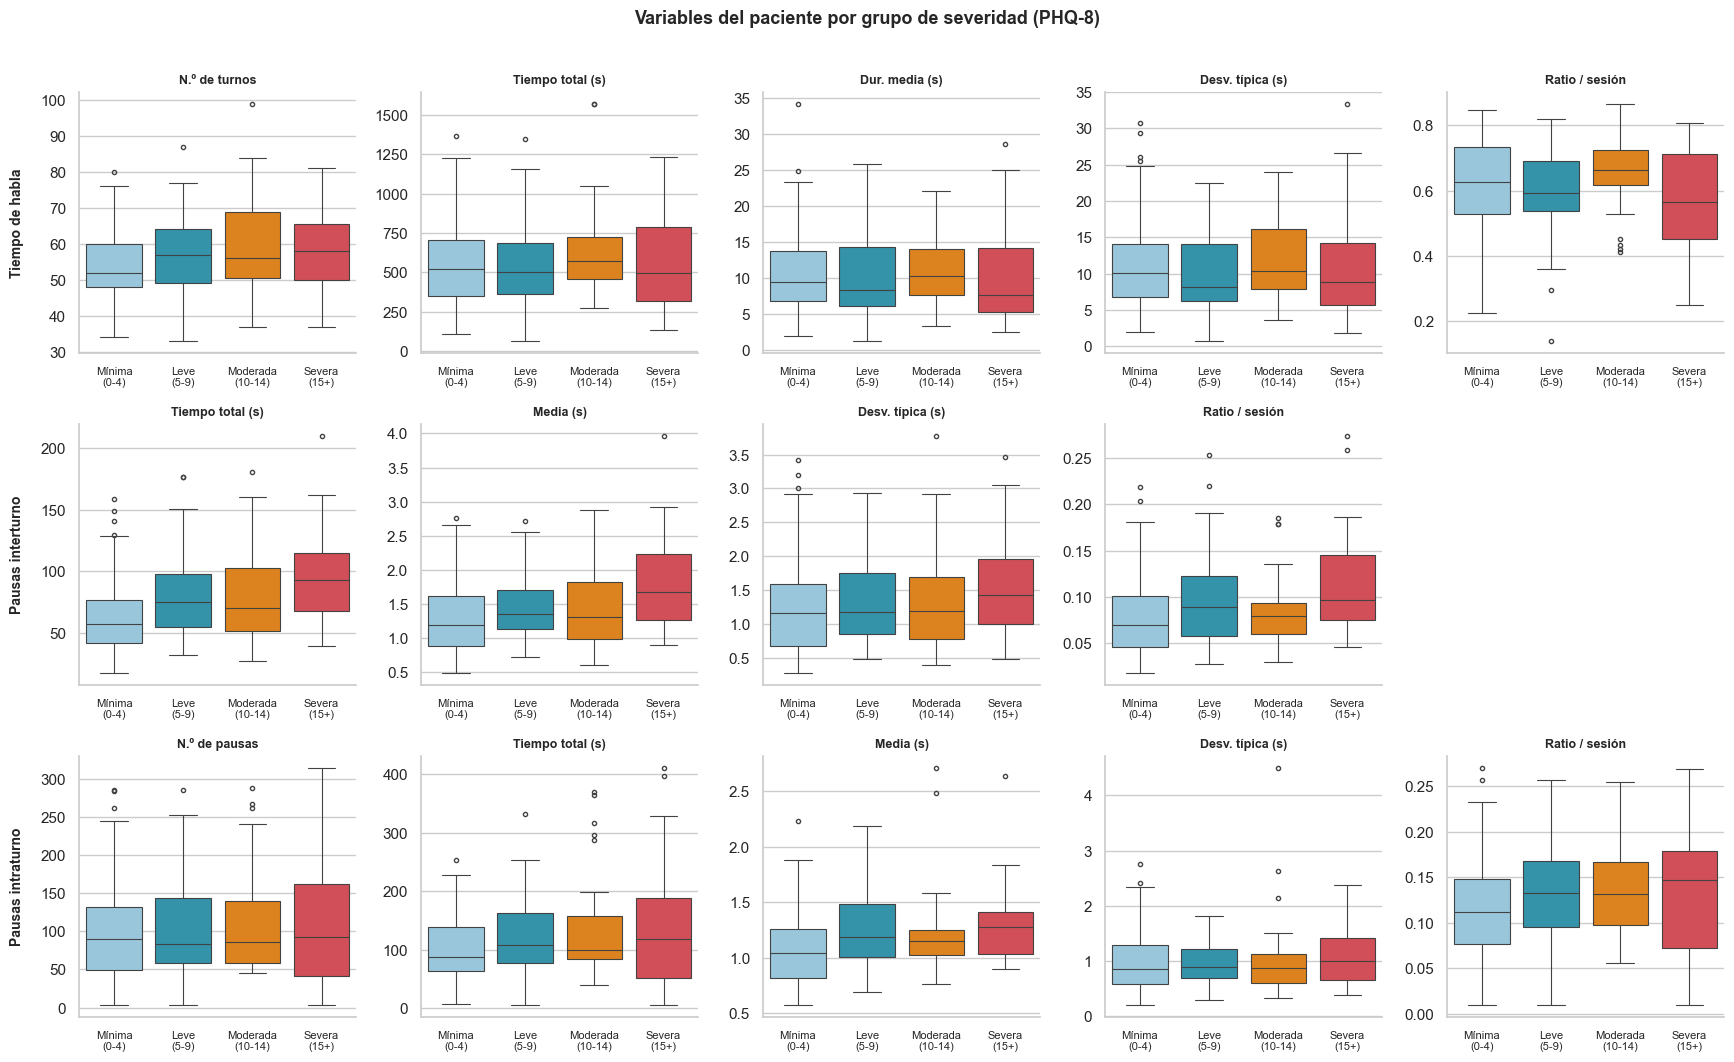

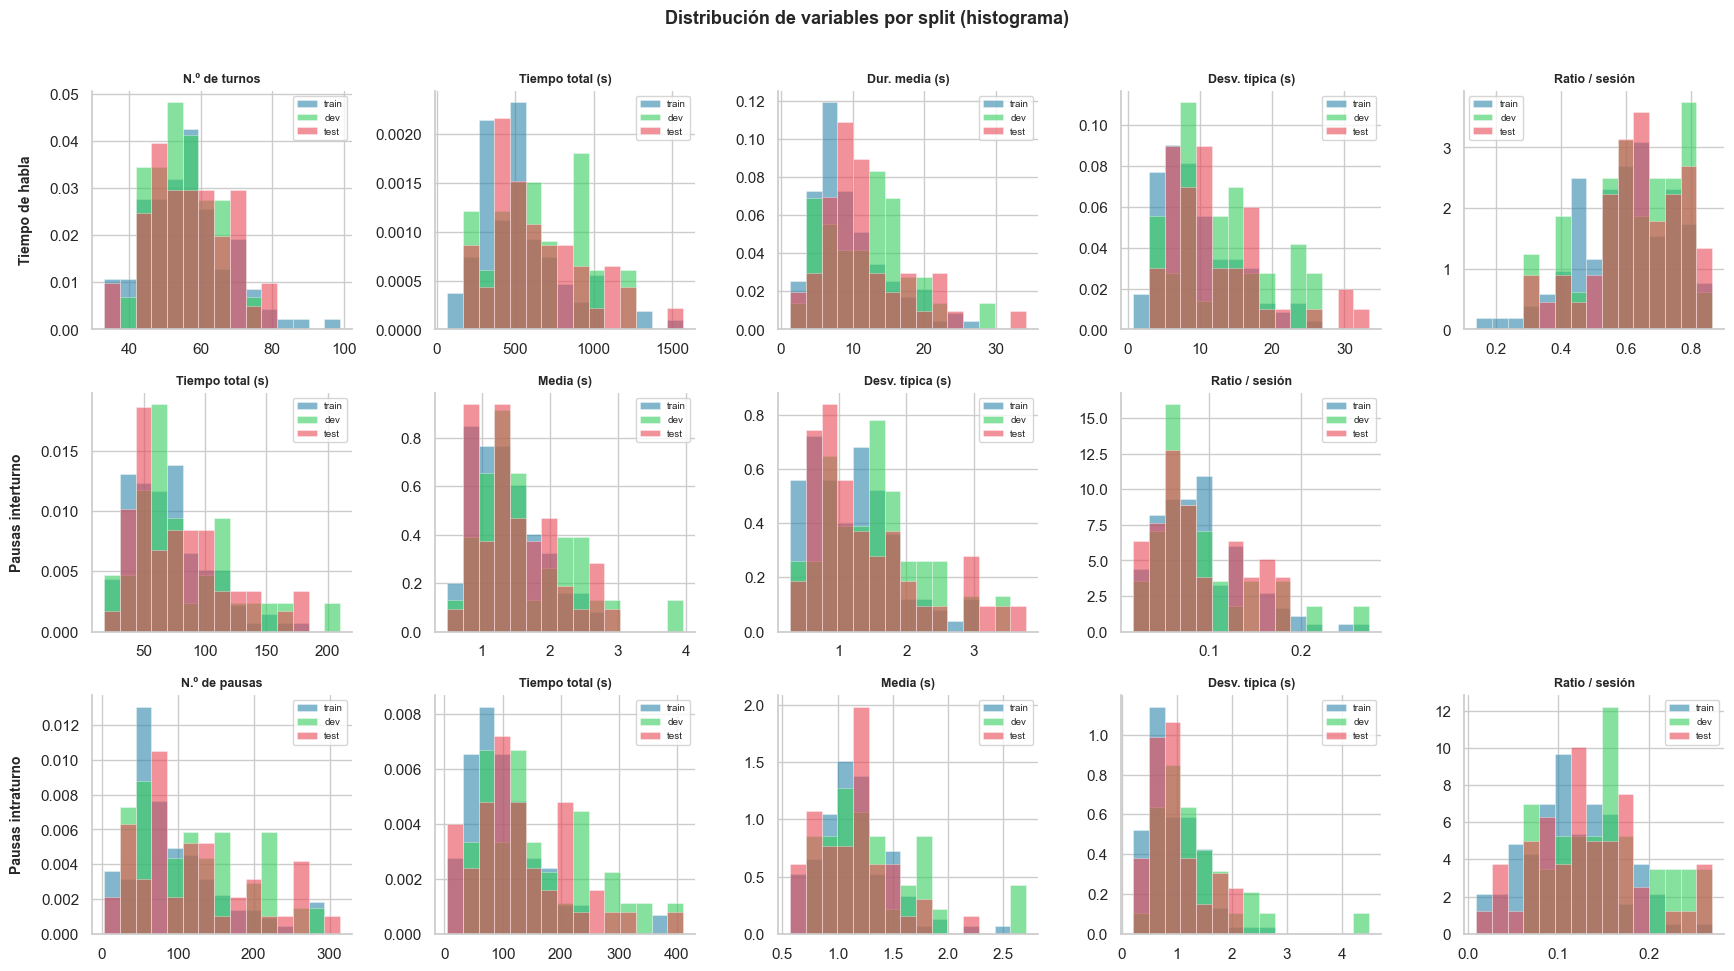

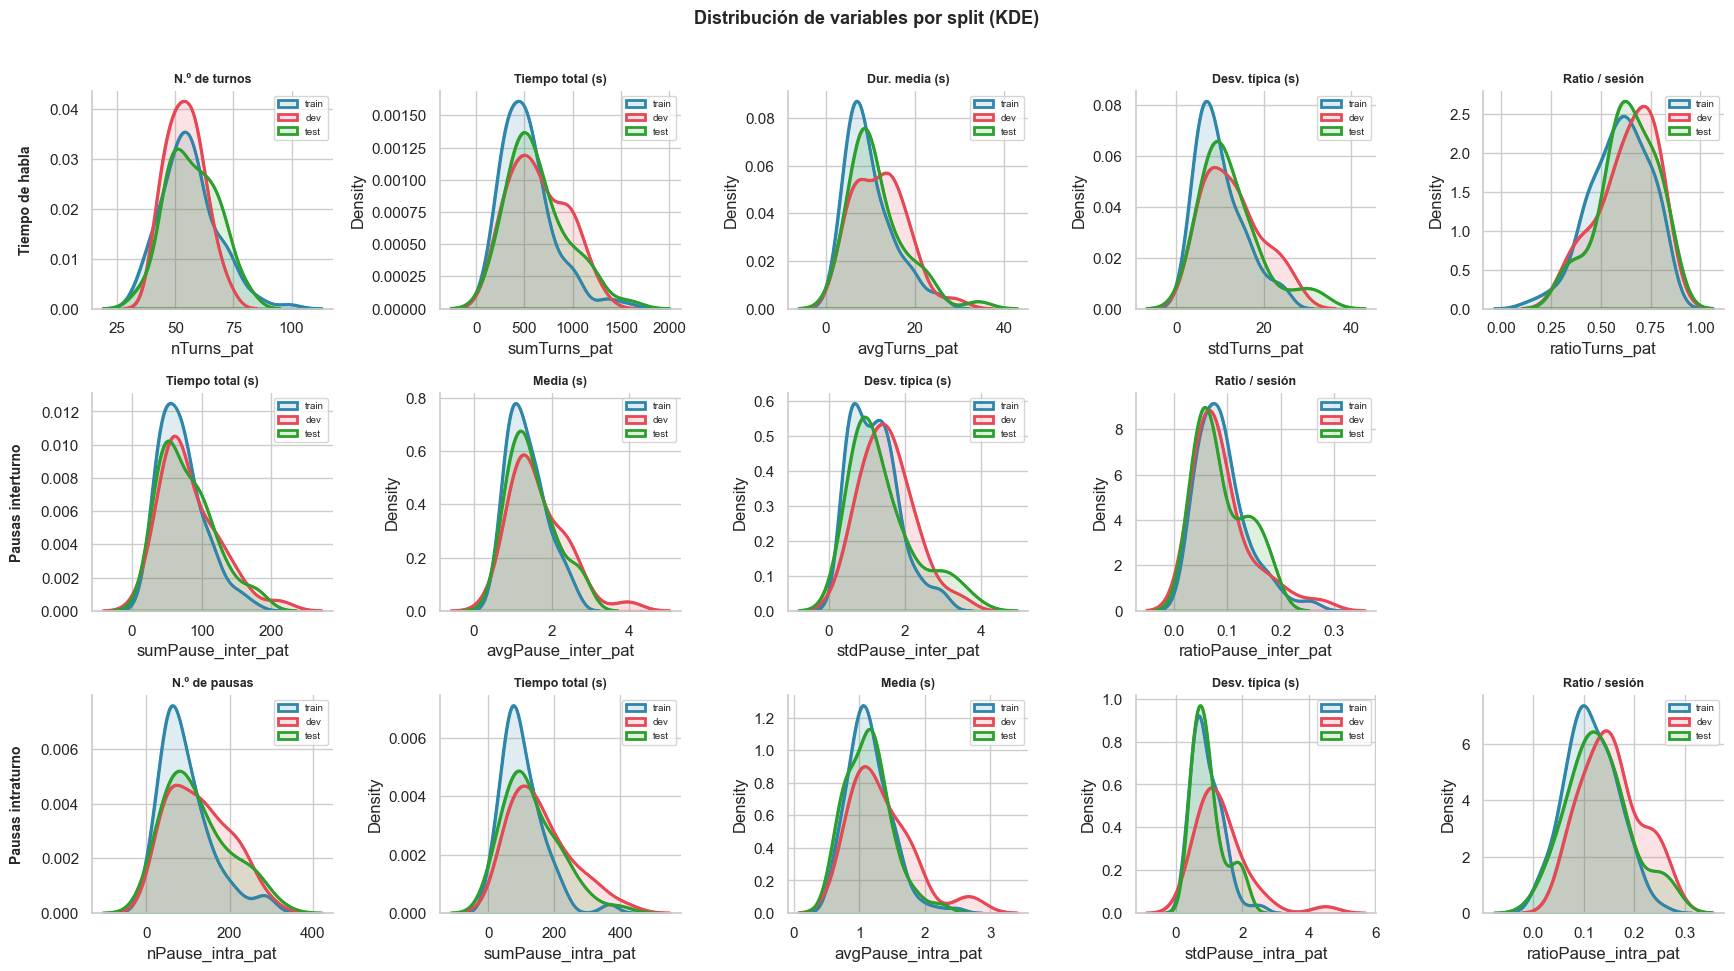

In [13]:
plot_phq8distribution_by_split(df_features_2)
plot_vars_vs_phq8(df_features_2)
plot_boxplots_by_severity(df_features_2)
plot_vars_by_split(df_features_2)
plot_vars_by_split_kde(df_features_2)

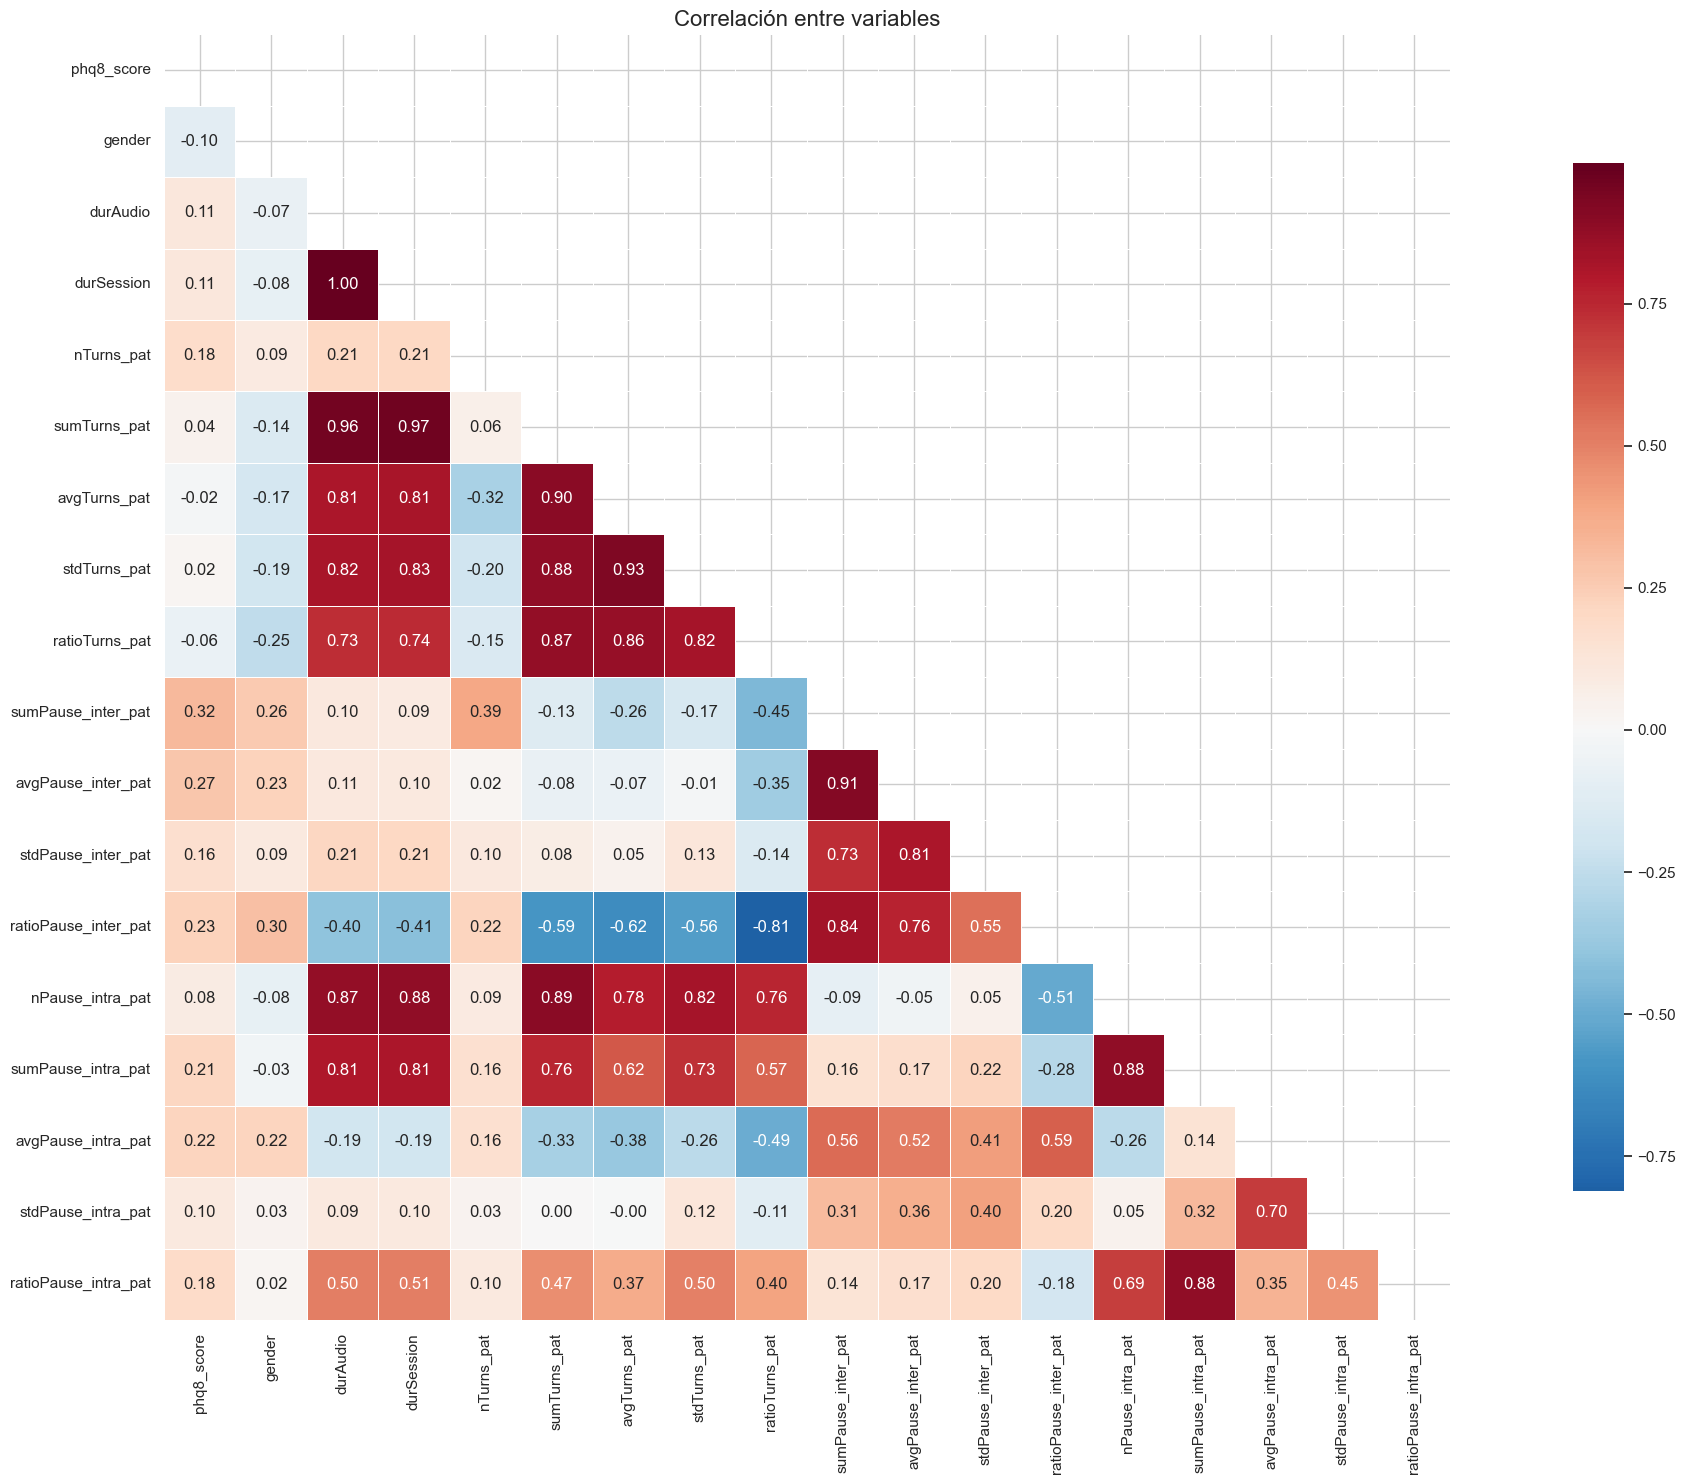

In [22]:
df_corr = df_features_2.drop(['participant_id', 'phq8_binary'], axis=1, errors='ignore')
corr = df_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(25, 15))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlación entre variables", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
# Se exporta el df final
df_features_2.to_csv(path_output / 'df_sample.csv', index=False)